In [19]:
import pandas as pd
import yfinance as yf
df=yf.download("TMCV.NS", start="2025-01-01", end="2026-01-01")
print(df.head())


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker         TMCV.NS     TMCV.NS     TMCV.NS     TMCV.NS    TMCV.NS
Date                                                                 
2025-11-12  325.772614  341.149029  316.428085  331.260651   31273277
2025-11-13  317.169708  322.361106  312.472729  313.066038   12079524
2025-11-14  314.054871  331.260641  302.880986  306.539698  165519798
2025-11-17  318.999054  321.866677  309.506206  318.207966   17163624
2025-11-18  321.520569  323.349925  306.539684  313.659327   13458307


In [14]:
!pip install pandas matplotlib yfinance


In [3]:
!pip install pandas matplotlib

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.7 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.9 MB 1.8 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.9 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.9 MB 1.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.9 MB 1.5 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.9 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.9 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.9 MB 1.1 MB/s eta 0:00:07
   --------- ------------------------------ 2.4/9.9 MB 1.1 MB/s eta 0:00:07
   ----------- ---------------------------- 2.9/9.9 MB 1.2 MB/s eta 0:00:06
   ------------ --------------------------- 3.1/9.9 MB 1.2 MB/s eta 0:00:06
   ------------- ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [6]:
import pandas as pd
df=pd.read_csv("tata_motors.csv")
print(df.head())
df.head(5)

         Date  Open  High  Low  Close   Volume
0  2024-06-01   950   960  940    955  1200000
1  2024-06-02   955   970  950    965  1400000
2  2024-06-03   965   980  960    975  1500000
3  2024-06-04   975   990  970    985  1600000
4  2024-06-05   985  1000  980    995  1700000


,Date,Open,High,Low,Close,Volume
0,2024-06-01,950,960,940,955,1200000
1,2024-06-02,955,970,950,965,1400000
2,2024-06-03,965,980,960,975,1500000
3,2024-06-04,975,990,970,985,1600000
4,2024-06-05,985,1000,980,995,1700000


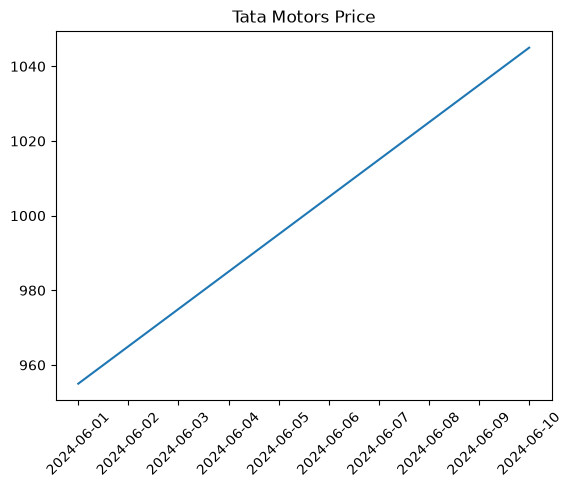

In [7]:
import matplotlib.pyplot as plt
df['Date'] = pd.to_datetime(df['Date'])

# Plot Close price
plt.figure()
plt.plot(df['Date'], df['Close'])
plt.title("Tata Motors Price")
plt.xticks(rotation=45)
plt.show()

In [8]:
# Create Moving Averages
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

# Check data
print(df[['Date', 'Close', 'MA20', 'MA50']].tail())

        Date  Close  MA20  MA50
5 2024-06-06   1005   NaN   NaN
6 2024-06-07   1015   NaN   NaN
7 2024-06-08   1025   NaN   NaN
8 2024-06-09   1035   NaN   NaN
9 2024-06-10   1045   NaN   NaN


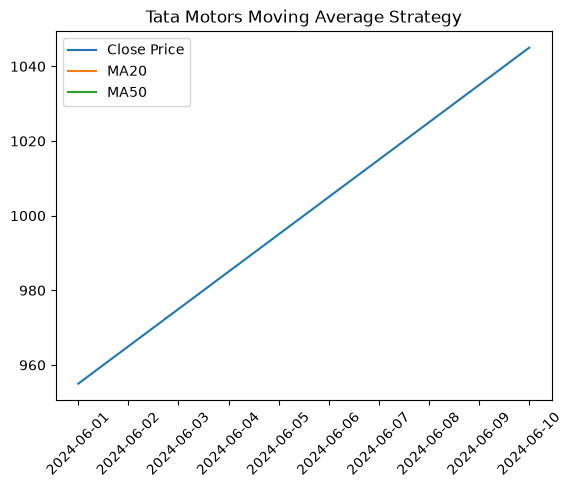

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA20'], label='MA20')
plt.plot(df['Date'], df['MA50'], label='MA50')

plt.legend()
plt.title("Tata Motors Moving Average Strategy")
plt.xticks(rotation=45)
plt.show()

In [10]:
# Create Signal column
df['Signal'] = 0

# When MA20 > MA50 → Buy (1), else Sell (0)
df['Signal'] = (df['MA20'] > df['MA50']).astype(int)

# Create Position (to detect crossover)
df['Position'] = df['Signal'].diff()

# Show where signals happen
print(df[['Date', 'Close', 'MA20', 'MA50', 'Signal', 'Position']].tail(20))

        Date  Close  MA20  MA50  Signal  Position
0 2024-06-01    955   NaN   NaN       0       NaN
1 2024-06-02    965   NaN   NaN       0       0.0
2 2024-06-03    975   NaN   NaN       0       0.0
3 2024-06-04    985   NaN   NaN       0       0.0
4 2024-06-05    995   NaN   NaN       0       0.0
5 2024-06-06   1005   NaN   NaN       0       0.0
6 2024-06-07   1015   NaN   NaN       0       0.0
7 2024-06-08   1025   NaN   NaN       0       0.0
8 2024-06-09   1035   NaN   NaN       0       0.0
9 2024-06-10   1045   NaN   NaN       0       0.0


In [20]:
plt.figure()

# Plot lines
plt.plot(df['Date'], df['Close'], label='Close', alpha=0.5)
plt.plot(df['Date'], df['MA20'], label='MA20')
plt.plot(df['Date'], df['MA50'], label='MA50')

# Buy signal (green)
plt.scatter(df[df['Position'] == 1]['Date'],
            df[df['Position'] == 1]['Close'],
            label='BUY', marker='^')

# Sell signal (red)
plt.scatter(df[df['Position'] == -1]['Date'],
            df[df['Position'] == -1]['Close'],
            label='SELL', marker='v')

plt.legend()
plt.title("Tata Motors Buy/Sell Signals")
plt.xticks(rotation=45)
plt.show()

KeyError: 'Date'

<Figure size 640x480 with 0 Axes>

In [21]:
df.columns = df.columns.droplevel(1)

In [22]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [23]:
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()

In [24]:
df['Signal'] = (df['MA20'] > df['MA50']).astype(int)
df['Position'] = df['Signal'].diff()

KeyError: 'Buy'

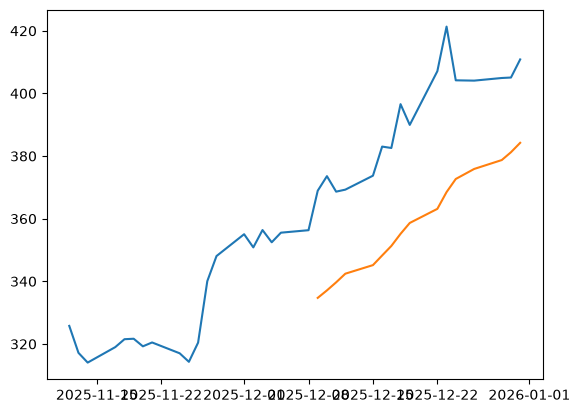

In [26]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df.index, df['Close'], label='Close')
plt.plot(df.index, df['MA20'], label='MA20')
plt.plot(df.index, df['MA50'], label='MA50')

plt.scatter(df[df['Position'] == 1].index,
            df[df['Position'] == 1]['Close'],
            label='BUY', marker='^')

plt.scatter(df[df['Position'] == -1].index,
            df[df['Position'] == -1]['Close'],
            label='SELL', marker='v')
plt.scatter(df[df['Buy']].index, df[df['Buy']]['Close'], marker='^')
plt.scatter(df[df['Sell']].index, df[df['Sell']]['Close'], marker='v')

plt.legend()
plt.title("Buy/Sell Signals")
plt.show()

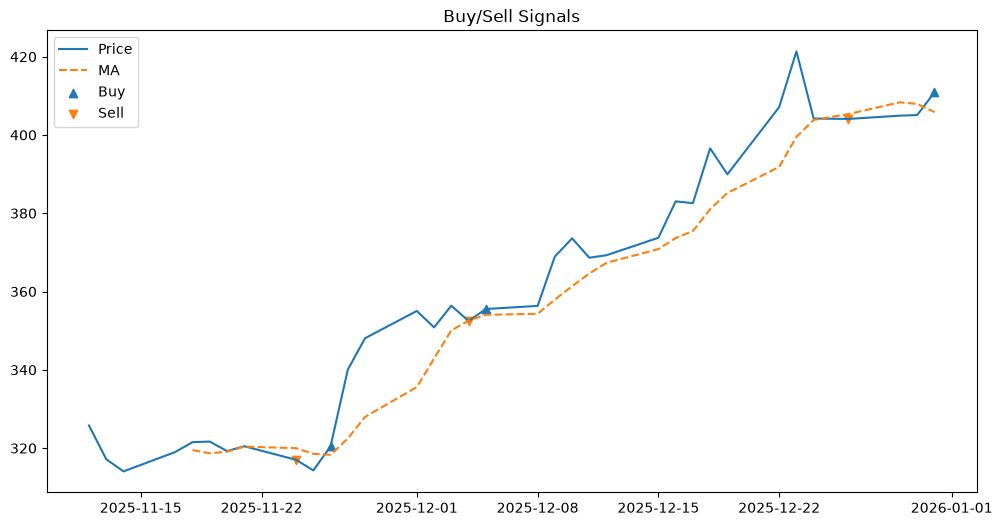

In [29]:
df['MA_fast'] = df['Close'].rolling(5).mean()
df['MA_slow'] = df['Close'].rolling(20).mean()

df['Buy'] = (df['MA_fast'] > df['MA_slow']) & (df['MA_fast'].shift(1) <= df['MA_slow'].shift(1))
df['Sell'] = (df['MA_fast'] < df['MA_slow']) & (df['MA_fast'].shift(1) >= df['MA_slow'].shift(1))

df['Buy'] = (df['Close'] > df['MA']) & (df['Close'].shift(1) <= df['MA'].shift(1))
df['Sell'] = (df['Close'] < df['MA']) & (df['Close'].shift(1) >= df['MA'].shift(1))

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Price line
plt.plot(df['Close'], label='Price')

# Moving Average
plt.plot(df['MA'], label='MA', linestyle='--')

# Buy signals (UP arrow)
plt.scatter(df[df['Buy']].index, df[df['Buy']]['Close'], 
            marker='^', label='Buy')

# Sell signals (DOWN arrow)
plt.scatter(df[df['Sell']].index, df[df['Sell']]['Close'], 
            marker='v', label='Sell')

plt.legend()
plt.title('Buy/Sell Signals')
plt.show()